<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Sesiones/Sesion_02e_reduccion_dim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# Reducción de la dimensionalidad

In [11]:
import numpy as np
import scipy as sp
import matplotlib.pylab as plt
from datascience import *
%matplotlib inline 

# Reduccion de dimensionalidad

## Principal Component Analysis PCA

El análisis de componentes principales (PCA) es una técnica estadística que se utiliza para reducir la dimensionalidad de un conjunto de datos, es decir, para representar los datos con menos variables sin perder mucha información. El PCA busca las combinaciones lineales de las variables originales que capturan la mayor parte de la variación o la dispersión de los datos. Estas combinaciones se llaman componentes principales, y se ordenan de mayor a menor importancia. El PCA se puede usar para explorar la estructura de los datos, para visualizarlos en un espacio de baja dimensión, o para prepararlos para otros análisis como la regresión o la clasificación.

Para entender mejor el PCA, puedes consultar la sección 3.2.1 y el apendice A de https://arxiv.org/pdf/2204.04198


Principal Component
Analysis,
Second Edition
http://cda.psych.uiuc.edu/statistical_learning_course/Jolliffe%20I.%20Principal%20Component%20Analysis%20(2ed.,%20Springer,%202002)(518s)_MVsa_.pdf



El Análisis de Componentes Principales (PCA, por sus siglas en inglés) es una técnica de álgebra lineal y estadística cuyo objetivo es encontrar nuevas direcciones ortogonales en el espacio de los datos tales que la proyección de los datos sobre esas direcciones tenga varianza máxima.

Sea una matriz de datos
\begin{equation}
X \in \mathbb{R}^{m \times n},
\end{equation}
donde $m$ es el número de observaciones y $n$ es el número de variables. Cada fila de $X$ representa una observación y cada columna representa una variable.

De manera explícita, la matriz de datos puede escribirse como
\begin{equation}
X =
\begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1n} \\
x_{21} & x_{22} & \cdots & x_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
x_{m1} & x_{m2} & \cdots & x_{mn}
\end{bmatrix}.
\end{equation}


Aquí, el elemento $x_{ij}$ representa el valor de la variable $j$ en la observación $i$.


## Interpretación geométrica de la matriz de datos

Cada observación puede verse como un vector en $\mathbb{R}^n$:
\begin{equation}
\mathbf{x}_i =
\begin{bmatrix}
x_{i1} \\
x_{i2} \\
\vdots \\
x_{in}
\end{bmatrix},
\qquad i=1,\dots,m.
\end{equation}


Por tanto, PCA estudia la geometría de la nube de puntos formada por los vectores $\mathbf{x}_1,\dots,\mathbf{x}_m$ en el espacio $\mathbb{R}^n$.


## Media de cada variable

El primer paso consiste en calcular la media de cada variable. Para la variable $j$, su media es
\begin{equation}
\mu_j = \frac{1}{m}\sum_{i=1}^{m} x_{ij},
\qquad j=1,\dots,n.
\end{equation}



Agrupando todas las medias en un vector columna, se define el vector media como
\begin{equation}
\boldsymbol{\mu} =
\begin{bmatrix}
\mu_1 \\
\mu_2 \\
\vdots \\
\mu_n
\end{bmatrix}
\in \mathbb{R}^{n}.
\end{equation}


## Centrado de los datos

Centrar los datos significa restar a cada observación el vector de medias. Si $\mathbf{1}_m \in \mathbb{R}^{m}$ denota el vector columna de unos,
\begin{equation}
\mathbf{1}_m =
\begin{bmatrix}
1 \\
1 \\
\vdots \\
1
\end{bmatrix},
\end{equation}
entonces la matriz centrada se define como
\begin{equation}
X_c = X - \mathbf{1}_m \boldsymbol{\mu}^T.
\end{equation}

De manera componente a componente,
\begin{equation}
(X_c)_{ij} = x_{ij} - \mu_j.
\end{equation}

Esto garantiza que cada columna de $X_c$ tenga media cero:
\begin{equation}
\frac{1}{m}\sum_{i=1}^{m} (X_c)_{ij} = 0,
\qquad \forall j=1,\dots,n.
\end{equation}


El centrado es esencial porque PCA busca direcciones de máxima dispersión respecto al centro de la nube de datos. Si no se centran los datos, la matriz de covarianza incorpora el desplazamiento del origen y las direcciones principales pueden quedar sesgadas por la media.

Geométricamente, centrar los datos traslada la nube de puntos para que su centro de masa quede en el origen.



## Matriz de covarianza

La matriz de covarianza de los datos centrados se define por
\begin{equation}
S = \frac{1}{m-1} X_c^T X_c.
\end{equation}

Aquí,
\begin{equation}
S \in \mathbb{R}^{n \times n}.
\end{equation}

El elemento $S_{jk}$ de la matriz de covarianza es
\begin{equation}
S_{jk} = \frac{1}{m-1}\sum_{i=1}^{m}(x_{ij}-\mu_j)(x_{ik}-\mu_k).
\end{equation}

En particular:

\begin{equation}
S_{jj} = \frac{1}{m-1}\sum_{i=1}^{m}(x_{ij}-\mu_j)^2
\end{equation}
es la varianza de la variable $j$, y para $j \neq k$,
\begin{equation}
S_{jk} = \frac{1}{m-1}\sum_{i=1}^{m}(x_{ij}-\mu_j)(x_{ik}-\mu_k)
\end{equation}
es la covarianza entre las variables $j$ y $k$.


La matriz $S$ tiene dos propiedades fundamentales:

\begin{equation}
S^T = S,
\end{equation}
es decir, es simétrica, y además es semidefinida positiva, pues para cualquier vector $\mathbf{a}\in\mathbb{R}^n$ se cumple

\begin{equation}
\mathbf{a}^T S \mathbf{a}
=
\frac{1}{m-1}\mathbf{a}^T X_c^T X_c \mathbf{a}
=
\frac{1}{m-1}\|X_c\mathbf{a}\|^2
\geq 0.
\end{equation}

Como consecuencia, todos sus autovalores son reales y no negativos, y sus autovectores asociados a autovalores distintos son ortogonales.


## Problema espectral

PCA se construye resolviendo el problema de autovalores y autovectores de la matriz de covarianza:
\begin{equation}
S \mathbf{v}_k = \lambda_k \mathbf{v}_k,
\qquad k=1,\dots,n.
\end{equation}

Aquí:

\begin{equation}
\lambda_k
\end{equation}
es el autovalor asociado al autovector
\begin{equation}
\mathbf{v}_k.
\end{equation}

Los autovalores se ordenan usualmente de mayor a menor:
\begin{equation}
\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_n \geq 0.
\end{equation}



##  Interpretación de autovalores y autovectores

Cada autovector $\mathbf{v}_k$ define una dirección en el espacio de variables. Esa dirección corresponde a un componente principal.

Cada autovalor $\lambda_k$ mide la varianza de los datos cuando se proyectan sobre la dirección $\mathbf{v}_k$.

Por tanto:

\begin{equation}
\text{primer componente principal} \longrightarrow \mathbf{v}_1
\end{equation}
es la dirección de máxima varianza,

\begin{equation}
\text{segundo componente principal} \longrightarrow \mathbf{v}_2
\end{equation}
es la dirección ortogonal a la anterior que captura la mayor varianza restante, y así sucesivamente.

## Componentes principales como combinaciones lineales

Cada componente principal es una combinación lineal de las variables originales. Si
\begin{equation}
\mathbf{v}_k =
\begin{bmatrix}
v_{1k} \\
v_{2k} \\
\vdots \\
v_{nk}
\end{bmatrix},
\end{equation}
entonces el componente principal $k$ para una observación centrada $\mathbf{x}$ está dado por
\begin{equation}
z_k = \mathbf{v}_k^T \mathbf{x}.
\end{equation}

Es decir,
\begin{equation}
z_k = v_{1k}x_1 + v_{2k}x_2 + \cdots + v_{nk}x_n.
\end{equation}


Si se agrupan los autovectores como columnas de una matriz
\begin{equation}
V =
\begin{bmatrix}
| & | &  & | \\
\mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_n \\
| & | &  & |
\end{bmatrix},
\end{equation}
entonces la transformación de los datos al sistema de componentes principales es
\begin{equation}
Z = X_c V.
\end{equation}

La matriz
\begin{equation}
Z \in \mathbb{R}^{m \times n}
\end{equation}
contiene las coordenadas de las observaciones en la nueva base definida por los componentes principales.

## Reducción de dimensionalidad

Si se desean conservar solo los primeros $r$ componentes principales, con $r<n$, se toma la matriz
\begin{equation}
V_r =
\begin{bmatrix}
| & | &  & | \\
\mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_r \\
| & | &  & |
\end{bmatrix}
\in \mathbb{R}^{n \times r}.
\end{equation}

La proyección reducida de los datos es entonces
\begin{equation}
Z_r = X_c V_r,
\end{equation}
donde
\begin{equation}
Z_r \in \mathbb{R}^{m \times r}.
\end{equation}

Así, cada observación original en $\mathbb{R}^n$ queda representada por un vector en $\mathbb{R}^r$, preservando la mayor parte de la variabilidad total.

## Varianza 

La varianza total de los datos es la suma de los autovalores:
\begin{equation}
\lambda_1 + \lambda_2 + \cdots + \lambda_n = \mathrm{tr}(S).
\end{equation}

La proporción de varianza explicada por el componente principal $k$ es
\begin{equation}
\frac{\lambda_k}{\sum_{j=1}^{n}\lambda_j}.
\end{equation}

La varianza acumulada explicada por los primeros $r$ componentes es
\begin{equation}
\frac{\sum_{k=1}^{r}\lambda_k}{\sum_{j=1}^{n}\lambda_j}.
\end{equation}

Esto permite decidir cuántos componentes conservar.

PCA transforma un conjunto de variables posiblemente correlacionadas en un nuevo conjunto de variables no correlacionadas, llamadas componentes principales, ordenadas según la cantidad de varianza que explican. Matemáticamente, esto se logra centrando los datos, construyendo la matriz de covarianza y resolviendo su problema espectral. Los autovectores definen las nuevas direcciones principales y los autovalores cuantifican la importancia de cada una.

# Intuición 

## Varianza 
 $x_i = x_i - \mu$

\begin{equation}
\mathrm{Var}(x)
\frac{1}{m-1}
\sum_{i=1}^{m}(x_i')^2
\end{equation}


\begin{equation}
\mathrm{Var}(x)
\frac{1}{m-1} x'^T x'
\end{equation}


In [12]:

datos = make_array(30, 31, 28, 29, 32, 33, 31, 28)
media=np.mean(datos)
datos_normalizos = datos-media


In [13]:
np.mean((datos_normalizos)**2)

2.9375

## Covarianza

La covarianza mide si dos variables varían juntas.

$x_i' = x_i - \mu_x$
$y_i' = y_i - \mu_y$

\begin{equation}
\mathrm{Cov}(x,y)
\frac{1}{m-1}
    \sum_{i=1}^{m}
(x_i-\mu_x)(y_i-\mu_y)
\end{equation}


\begin{equation}
\mathrm{Cov}(x,y)
\frac{1}{m-1}
x'^T y'
\end{equation}


la covarianza es un producto interno entre variables.

In [14]:
nadador = make_array(1, 2, 3, 4, 5)
x_brazadas = make_array(28, 30, 31, 32, 27)
y_velocidad = make_array(1.4,1.5, 1.5, 1.7, 1.4)

In [15]:
(np.dot((x_brazadas-np.mean(x_brazadas)), (y_velocidad-np.mean(y_velocidad))))/5

0.18000000000000005

## PCA

In [31]:
#Datos centrados en cero
x1 = np.linspace(-1, 1,10)
x2 = np.linspace(-1, 1,10) + (2*np.random.random(10)-1)

In [32]:
print(x1.mean())
x1 = x1 - x1.mean()
print(x1.mean())

-2.22044604925e-17
-2.22044604925e-17


In [33]:
print(x2.mean())
x2 = x2 - x2.mean()
print(x2.mean())

-0.00946762447874
0.0


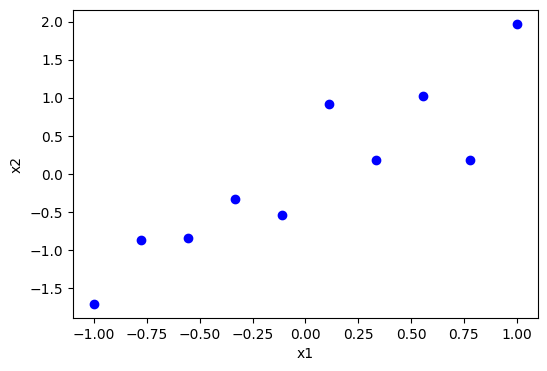

In [35]:
plt.figure(figsize= (6, 4))
plt.plot(x1, x2,"bo")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [68]:
X = np.stack((x1, x2), axis = 0)
X

array([[-1.        , -0.77777778, -0.55555556, -0.33333333, -0.11111111,
         0.11111111,  0.33333333,  0.55555556,  0.77777778,  1.        ],
       [-1.70456409, -0.86284821, -0.84008973, -0.32787464, -0.53686594,
         0.91123153,  0.18732972,  1.02405211,  0.17826526,  1.97136399]])

In [69]:
A = np.cov(X)
A

array([[ 0.4526749 ,  0.6504391 ],
       [ 0.6504391 ,  1.17596621]])

In [70]:
M = np.matrix(A)
M

matrix([[ 0.4526749 ,  0.6504391 ],
        [ 0.6504391 ,  1.17596621]])

In [71]:
# Autovalores y autovectores
E,U = np.linalg.eig(M)

In [72]:
U

matrix([[-0.86195745, -0.50698063],
        [ 0.50698063, -0.86195745]])

In [73]:
U1 = np.array(U[:,0])
U2 = np.array(U[:,1])

In [74]:
U2

array([[-0.50698063],
       [-0.86195745]])

In [75]:
E

array([ 0.07010378,  1.55853732])

In [76]:
#comparar a M
#r = (np.matrix(X) @ np.matrix(X).T) /10

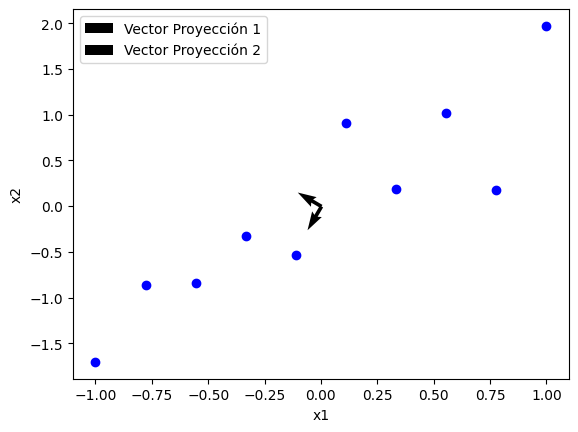

In [77]:
plt.figure()
plt.plot(x1, x2,"bo")
plt.quiver(0,0,U1[0][0],U1[1][0], label = "Vector Proyección 1")
plt.quiver(0,0,U2[0][0],U2[1][0], label = "Vector Proyección 2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

In [78]:
#Proyectamos los datos X en el subespacio reducido de manera que queda una sola variable P
P = U2.T@X
P

array([[ 1.97624234,  1.13805671,  1.0057775 ,  0.45160753,  0.51908678,
        -0.84177399, -0.33046379, -1.16434525, -0.54797533, -2.2062125 ]])

In [79]:
U2[1][0]

-0.86195744933409635

In [80]:
# Pendiente
m = np.arctan(U2[1][0]/U2[0][0])
m

1.0391180862798186

In [81]:
x2r = x1*np.tan(m)

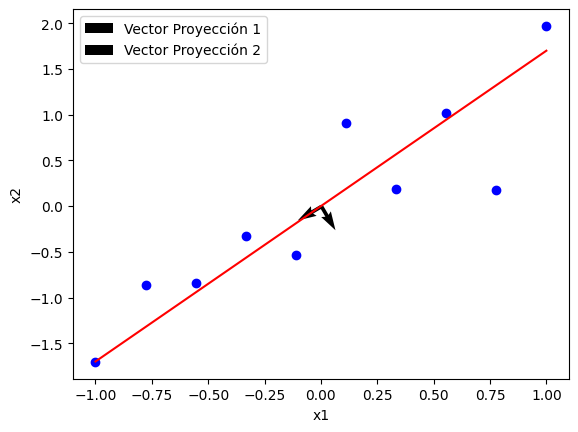

In [82]:
plt.figure()
plt.plot(x1, x2,"bo")
plt.quiver(0,0,U1[1][0],U1[0][0], label = "Vector Proyección 1")
plt.quiver(0,0,U2[1][0],U2[0][0], label = "Vector Proyección 2")
plt.plot(x1, x2r,"r-")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()


Observamos que los datos tienen la mayor varianza posible sobre la proyección del primer vector. Esta es una propiedad algebraica que se puede aprovechar para decidir quedarse con los datos proyectados sobre un subespacio mas pequeño que el original con una varianza mayor a ciertdo valor treshold.

El algoritmo quedaría de esta manera (tomado de la referencia indicada arriba):

Algoritmo: Principal component analysis (PCA)

Requiere: Hyperparametro k (la dimensionalidad de los datos proyectados)
En el ejemplo anterior de dos dimensiones que se pueden reducir a una dimension escogeriamos k=1.

Requiere: Matriz X ∈ Rn×m
En el ejemplo anterior de los datos m=2 variables con cada una n=10 records  

Paso 1: En este paso quitamos de manera que cada variable esta centrada en cero.
X ← X − mean(X)

Paso 2: Construimos la matriz de covarianza empírica Σ a partir de XᵀX/n

Paso 3: Calculamos los vectores propios y los ordenamos por el valor de mayor a menor de sus valores propios
V ← Eigenvectors(Σ) 

Paso 4: Construimos la matriz V˜ para hacer la proyección en el espacio reducido de los primeros k-vectores propios
V˜ ← V [:, : k] 

Paso 5: Proyectamos los datos X en el espacio reducido para retornar X˜
X˜ ← X V˜ ∈ Rn×k

In [29]:
#Usando PCA en sklearn

from sklearn.decomposition import PCA

# Combinar en una matriz (10 muestras x 2 variables)
X = np.column_stack((x1, x2))

# Crear el modelo PCA para reducir a 1 componente
pca = PCA(n_components=1)

# Ajustar PCA y transformar los datos
X_pca = pca.fit_transform(X)

print("Datos originales:\n", X)
print("\nDatos transformados (1 componente principal):\n", X_pca)

# Información adicional
print("\nVarianza explicada:", pca.explained_variance_ratio_)
print("Componentes principales:\n", pca.components_)

Datos originales:
 [[-1.         -0.61109405]
 [-0.77777778 -1.68976988]
 [-0.55555556 -0.7639162 ]
 [-0.33333333 -0.28631203]
 [-0.11111111  0.53834717]
 [ 0.11111111 -0.02426071]
 [ 0.33333333  1.30870123]
 [ 0.55555556 -0.22205652]
 [ 0.77777778  0.70481777]
 [ 1.          1.04554322]]

Datos transformados (1 componente principal):
 [[-1.06589582]
 [-1.83575939]
 [-0.94398363]
 [-0.42378086]
 [ 0.38411052]
 [ 0.04203751]
 [ 1.27128253]
 [ 0.12666912]
 [ 1.01929091]
 [ 1.42602912]]

Varianza explicada: [0.89838263]
Componentes principales:
 [[0.5593341  0.82894231]]


## Otras opciones en sklearn


Ver la sección Feature selection en sklearn